In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X_train = pd.read_csv("../data/X_rf_train.csv")
X_test = pd.read_csv("../data/X_rf_test.csv")
y_train = pd.read_csv("../data/y_train.csv")
y_test = pd.read_csv("../data/y_test.csv")

In [3]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [5]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [6]:
from sklearn.neural_network import MLPRegressor

In [7]:
ann = MLPRegressor(
    hidden_layer_sizes=(200,100,50),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    learning_rate="adaptive",
    max_iter=2000,
    random_state=42
)

In [8]:
ann.fit(
    X_train_scaled,
    y_train
)

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(200, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'adaptive'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",2000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [9]:
y_train_pred = ann.predict(
    X_train_scaled
)

y_pred = ann.predict(
    X_test_scaled
)

In [10]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [11]:
train_r2 = r2_score(
    y_train,
    y_train_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("Train R2:",round(train_r2,4))

print()

print("Test Metrics")

print("R2 :",round(r2,4))

print("MAE :",round(mae,4))

print("RMSE :",round(rmse,4))

Train R2: 0.9821

Test Metrics
R2 : 0.9664
MAE : 0.0467
RMSE : 0.1051


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ann", MLPRegressor(
        hidden_layer_sizes=(128,64,32),
        activation="relu",
        solver="adam",
        max_iter=2000,
        random_state=42
    ))
])

In [13]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=10,
    scoring="r2",
    n_jobs=-1
)

In [14]:
print("Fold Scores:")
print(cv_scores)
print()
print("Mean CV R2:",round(cv_scores.mean(),4))
print("Std CV R2:",round(cv_scores.std(),4))

Fold Scores:
[0.97920258 0.96268828 0.97738921 0.98441324 0.97798327 0.97603338
 0.97291525 0.97717799 0.98003244 0.97570588]

Mean CV R2: 0.9764
Std CV R2: 0.0054


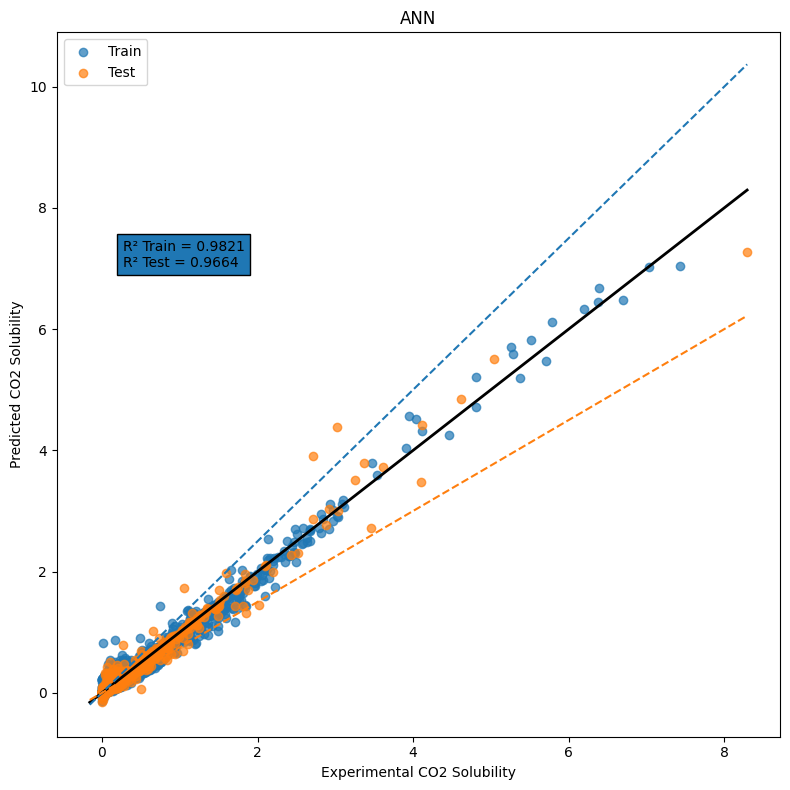

In [15]:
all_values = np.concatenate([
    y_train,
    y_test,
    y_train_pred,
    y_pred
])

xmin = all_values.min()
xmax = all_values.max()

# Perfect prediction line
x_line = np.linspace(xmin, xmax, 100)

# ±25%
upper = x_line * 1.25
lower = x_line * 0.75

plt.figure(figsize=(8,8))

# Train
plt.scatter(
    y_train,
    y_train_pred,
    label="Train",
    alpha=0.7
)

# Test
plt.scatter(
    y_test,
    y_pred,
    label="Test",
    alpha=0.7
)

# Perfect prediction
plt.plot(
    x_line,
    x_line,
    color="black",
    linewidth=2
)

# +25%
plt.plot(
    x_line,
    upper,
    linestyle="--"
)

# -25%
plt.plot(
    x_line,
    lower,
    linestyle="--"
)

plt.xlabel("Experimental CO2 Solubility")
plt.ylabel("Predicted CO2 Solubility")

plt.legend()

plt.text(
    xmin + 0.05*(xmax-xmin),
    xmax - 0.15*(xmax-xmin),
    f"R² Train = {train_r2:.4f}\nR² Test = {r2:.4f}",
    bbox=dict()
)

plt.title("ANN")

plt.tight_layout()

plt.show()

In [17]:
train_error = y_train - y_train_pred
test_error = y_test - y_pred


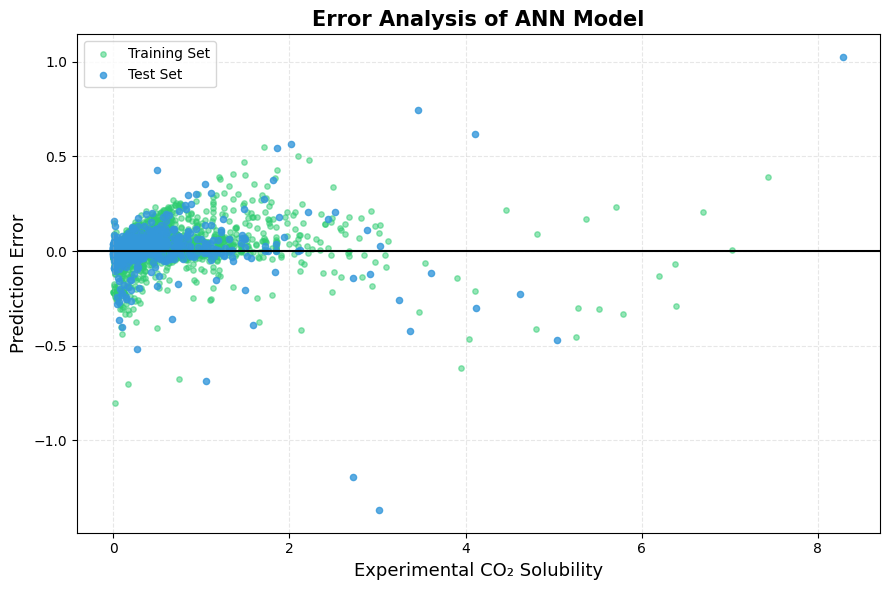

In [24]:
plt.figure(figsize=(9,6))

plt.scatter(
    y_train,
    train_error,
    c="#2ecc71",
    alpha=0.5,
    s=15,
    label="Training Set"
)

plt.scatter(
    y_test,
    test_error,
    c="#3498db",
    alpha=0.8,
    s=20,
    label="Test Set"
)

plt.axhline(
    0,
    color="black",
    linewidth=1.5
)

plt.xlabel(
    "Experimental CO₂ Solubility",
    fontsize=13
)

plt.ylabel(
    "Prediction Error",
    fontsize=13
)

plt.title(
    "Error Analysis of ANN Model",
    fontsize=15,
    fontweight="bold"
)

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

In [19]:
train_error = np.array(train_error).flatten()
test_error = np.array(test_error).flatten()

xmin = min(train_error.min(), test_error.min())
xmax = max(train_error.max(), test_error.max())

In [20]:
from scipy.stats import norm

In [21]:
print(train_error.min(), train_error.max())
print(test_error.min(), test_error.max())

-0.8033711172708052 0.5491673270369166
-1.367996145373405 1.0257181834358917


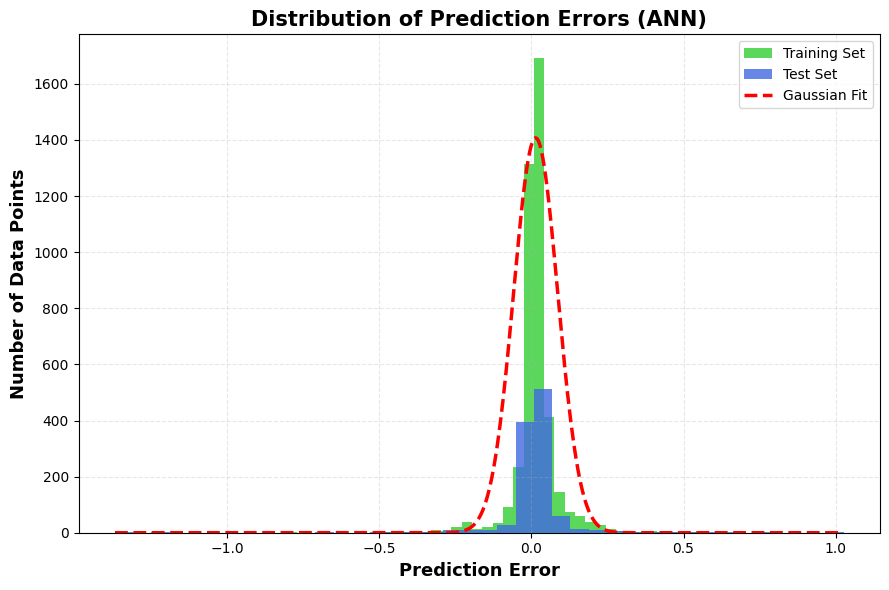

In [23]:
mu_train, sigma_train = norm.fit(train_error)

# Fit Gaussian on test errors
mu_test, sigma_test = norm.fit(test_error)

# Create x values
xmin = min(train_error.min(), test_error.min())
xmax = max(train_error.max(), test_error.max())

x = np.linspace(xmin, xmax, 500)

# Plot
plt.figure(figsize=(9,6))

# Training histogram
plt.hist(
    train_error,
    bins=40,
    color="limegreen",
    alpha=0.8,
    label="Training Set"
)

# Test histogram
plt.hist(
    test_error,
    bins=40,
    color="royalblue",
    alpha=0.8,
    label="Test Set"
)

# Gaussian curves
plt.plot(
    x,
    norm.pdf(x, mu_train, sigma_train) * len(train_error) * (xmax-xmin)/40,
    'r--',
    linewidth=2.5,
    label="Gaussian Fit"
)

plt.xlabel(
    "Prediction Error",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Number of Data Points",
    fontsize=13,
    fontweight="bold"
)

plt.title(
    "Distribution of Prediction Errors (ANN)",
    fontsize=15,
    fontweight="bold"
)

plt.legend(
    fontsize=10
)

plt.grid(
    linestyle="--",
    alpha=0.3
)


plt.tight_layout()

plt.show()

In [25]:
df=pd.read_csv("../data/DataWithDescriptors.csv")
df.columns

Index(['Unnamed: 0', 'IL NAME', 'CATION NAME', 'ANION NAME', 'Cation_SMILES',
       'Anion_SMILES', 'Temperature (0 C)', 'Pressure (bar)',
       'CO2 capacity (mol CO2/mol IL)', 'Cation_Family',
       ...
       'An_fr_sulfide', 'An_fr_sulfonamd', 'An_fr_sulfone',
       'An_fr_term_acetylene', 'An_fr_tetrazole', 'An_fr_thiazole',
       'An_fr_thiocyan', 'An_fr_thiophene', 'An_fr_unbrch_alkane',
       'An_fr_urea'],
      dtype='str', length=444)

In [27]:
rf_features = features.iloc[:,0].tolist()

print(rf_features)
print(len(rf_features))

['Pressure (bar)', 'Temperature (0 C)', 'Cat_MolLogP', 'Cat_EState_VSA2', 'An_TPSA', 'Cat_VSA_EState3', 'An_AvgIpc', 'An_SlogP_VSA1', 'Cat_TPSA', 'Cat_EState_VSA9', 'Cat_BCUT2D_LOGPLOW', 'Cat_NumHDonors', 'Cat_SMR_VSA5', 'Cat_SMR_VSA1', 'Cat_PEOE_VSA1', 'Cat_NHOHCount', 'Cat_EState_VSA8', 'Cat_Chi4v', 'An_BalabanJ', 'An_PEOE_VSA3']
20


In [28]:
ranged_df=df[(df["Temperature (0 C)"] >= 25) &(df["Temperature (0 C)"] <= 30) &(df["Pressure (bar)"] >= 0.5) &(df["Pressure (bar)"] <= 1.5)].copy()

In [42]:
X_ranged.head()

,Pressure (bar),Temperature (0 C),Cat_MolLogP,Cat_EState_VSA2,An_TPSA,Cat_VSA_EState3,An_AvgIpc,An_SlogP_VSA1,Cat_TPSA,Cat_EState_VSA9,Cat_BCUT2D_LOGPLOW,Cat_NumHDonors,Cat_SMR_VSA5,Cat_SMR_VSA1,Cat_PEOE_VSA1,Cat_NHOHCount,Cat_EState_VSA8,Cat_Chi4v,An_BalabanJ,An_PEOE_VSA3
14,1.0,30.0,-0.33860,0.0,82.38,0.000000,1.772997,0.000000,34.83,5.733667,-2.234250,1,12.965578,4.567100,5.733667,2,17.091263,0.907846,5.284513,16.835594
15,1.0,30.0,-0.99858,0.0,0.00,0.000000,0.000000,16.981451,60.85,11.467335,-2.387640,2,20.013250,4.567100,11.467335,4,16.057937,1.292517,0.000000,0.000000
16,1.0,27.0,-2.63380,0.0,28.64,6.414184,1.719973,10.633577,77.72,5.733667,-2.542194,4,0.000000,5.733667,22.100912,7,16.367245,0.653839,2.000000,0.000000
17,1.0,27.0,-2.63380,0.0,26.99,6.414184,1.760495,4.983979,77.72,5.733667,-2.542194,4,0.000000,5.733667,22.100912,7,16.367245,0.653839,3.125000,0.000000
18,1.0,27.0,-2.63380,0.0,26.99,6.414184,1.760495,5.098682,77.72,5.733667,-2.542194,4,0.000000,5.733667,22.100912,7,16.367245,0.653839,3.125000,0.000000


In [29]:
X_ranged = ranged_df[rf_features]

X_ranged_scaled = scaler.transform(X_ranged)

In [31]:
ranged_df["SVR_Pred"] = ann.predict(
    X_ranged_scaled
)

In [32]:
rf_ranking = (ranged_df.groupby("IL NAME")["SVR_Pred"].mean().reset_index())

In [33]:
top5_rf = rf_ranking.sort_values(by="SVR_Pred",ascending=False).head(10)

print(top5_rf)

          IL NAME  SVR_Pred
68    [TETAH][Pz]  2.066400
1     [AmemI][Br]  1.735898
67    [TETAH][Py]  1.448850
69    [TETAH][Tz]  1.437862
66    [TETAH][Im]  1.435969
71  [aP4443][Ala]  1.093070
62  [P66614][Sar]  1.061233
57  [P66614][Gly]  1.033308
56  [P66614][Ala]  1.019614
61  [P66614][Pro]  1.000230


In [50]:
x=df[rf_features]
X_scaled = scaler.transform(x)


In [54]:
y_all_pred = ann.predict(X_scaled)

family_results = pd.DataFrame({
    "Actual": df["CO2 capacity (mol CO2/mol IL)"],
    "Predicted":  y_all_pred.ravel(),
    "Family": df["Cation_Family"].values
})

In [56]:
print(family_results["Family"].value_counts())

Family
Imidazolium         3851
Ammonium             512
Pyrrolidinium        374
Phosphonium          272
Pyridinium           182
Guanidinium           42
Sulfonium             39
Cyclopropenylium      39
Piperidinium          36
Amidinium              2
Name: count, dtype: int64


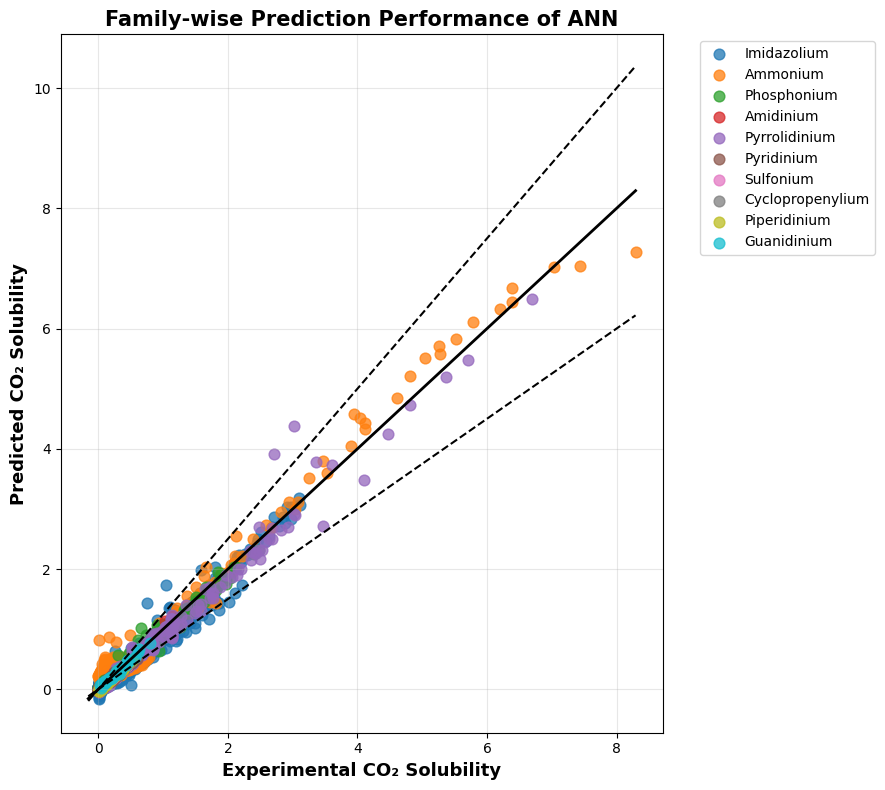

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(9,8))

families = family_results["Family"].unique()

for family in families:

    temp = family_results[
        family_results["Family"] == family
    ]

    plt.scatter(
        temp["Actual"],
        temp["Predicted"],
        s=60,
        alpha=0.75,
        label=family
    )

# Perfect prediction line
mn = min(
    family_results["Actual"].min(),
    family_results["Predicted"].min()
)

mx = max(
    family_results["Actual"].max(),
    family_results["Predicted"].max()
)

plt.plot(
    [mn,mx],
    [mn,mx],
    color="black",
    linewidth=2
)

# +25%
plt.plot(
    [mn,mx],
    [mn*1.25,mx*1.25],
    "--",
    color="black"
)

# -25%
plt.plot(
    [mn,mx],
    [mn*0.75,mx*0.75],
    "--",
    color="black"
)

plt.xlabel(
    "Experimental CO₂ Solubility",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Predicted CO₂ Solubility",
    fontsize=13,
    fontweight="bold"
)

plt.title(
    "Family-wise Prediction Performance of ANN",
    fontsize=15,
    fontweight="bold"
)

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()